<a href="https://colab.research.google.com/github/mritu2000-bit/landsat-l1-processing-pipeline/blob/main/L1_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install rasterio

In [3]:
import os
print(os.listdir('/content'))

['.config', 'Data', '.ipynb_checkpoints', 'sample_data']


In [4]:
print(os.listdir('/content/Data'))

['subset_B4.TIF']


In [5]:
with rasterio.open('/content/Data/subset_B4.TIF') as src:
    print("Width:", src.width)
    print("Height:", src.height)
    print("CRS:", src.crs)
    print("Transform:", src.transform)
    band4 = src.read(1).astype(np.float32)
    profile = src.profile

print("Min DN:", np.min(band4))
print("Max DN:", np.max(band4))
print("Shape:", band4.shape)

Width: 500
Height: 500
CRS: EPSG:32643
Transform: | 30.00, 0.00, 758985.00|
| 0.00,-30.00, 3221415.00|
| 0.00, 0.00, 1.00|
Min DN: 15802.0
Max DN: 54566.0
Shape: (500, 500)


In [6]:
# Radiometric correction
ML = 9.9729e-03
AL = -49.86461
Mp = 2.0000E-05
Ap = -0.100000
sun_elevation = 63.16

# Mask no data
band4[band4 == 0] = np.nan

# TOA Reflectance
toa = (Mp * band4 + Ap) / math.sin(math.radians(sun_elevation))
toa[toa > 1] = np.nan
toa[toa < 0] = np.nan

# Atmospheric correction
atm_intrinsic = 0.035
gas_trans = 0.943
sph_albedo = 0.089

y = toa - atm_intrinsic
sr = y / (gas_trans * (1 + sph_albedo * y))
sr[sr > 1] = np.nan
sr[sr < 0] = np.nan

print("TOA Min:", round(np.nanmin(toa), 4), "Max:", round(np.nanmax(toa), 4))
print("Surface Min:", round(np.nanmin(sr), 4), "Max:", round(np.nanmax(sr), 4))
print("Radiometric correction done.")

TOA Min: 0.2421 Max: 1.0
Surface Min: 0.2157 Max: 0.9424
Radiometric correction done.


In [7]:
from rasterio.control import GroundControlPoint
from rasterio.transform import from_gcps
import rasterio

# Current transform from your file
print("Current CRS:", profile['crs'])
print("Current Transform:", profile['transform'])

# Define 4 Ground Control Points
# Format: GroundControlPoint(row, col, x_real, y_real)
# These are approximate GCPs based on your transform
transform = profile['transform']

gcps = [
    GroundControlPoint(0, 0,
                      transform.c,
                      transform.f),
    GroundControlPoint(0, 499,
                      transform.c + 499 * transform.a,
                      transform.f),
    GroundControlPoint(499, 0,
                      transform.c,
                      transform.f + 499 * transform.e),
    GroundControlPoint(499, 499,
                      transform.c + 499 * transform.a,
                      transform.f + 499 * transform.e),
]

for i, gcp in enumerate(gcps):
    print(f"GCP {i+1}: row={gcp.row}, col={gcp.col}, x={gcp.x}, y={gcp.y}")

Current CRS: EPSG:32643
Current Transform: | 30.00, 0.00, 758985.00|
| 0.00,-30.00, 3221415.00|
| 0.00, 0.00, 1.00|
GCP 1: row=0, col=0, x=758985.0, y=3221415.0
GCP 2: row=0, col=499, x=773955.0, y=3221415.0
GCP 3: row=499, col=0, x=758985.0, y=3206445.0
GCP 4: row=499, col=499, x=773955.0, y=3206445.0


In [8]:
from rasterio.transform import from_gcps
from rasterio.crs import CRS
import numpy as np

# Compute new transform from GCPs
new_transform = from_gcps(gcps)

print("Old Transform:", profile['transform'])
print("New Transform:", new_transform)

# Save geometrically corrected output
corrected_profile = profile.copy()
corrected_profile.update({
    'dtype': rasterio.float32,
    'transform': new_transform,
    'crs': CRS.from_epsg(32643)
})

with rasterio.open('/content/Data/band4_corrected.TIF', 'w', **corrected_profile) as dst:
    dst.write(sr.astype(np.float32), 1)

print("Geometrically corrected file saved.")

# Verify
with rasterio.open('/content/Data/band4_corrected.TIF') as src:
    print("Verified CRS:", src.crs)
    print("Verified Transform:", src.transform)
    print("Width:", src.width, "Height:", src.height)

Old Transform: | 30.00, 0.00, 758985.00|
| 0.00,-30.00, 3221415.00|
| 0.00, 0.00, 1.00|
New Transform: | 30.00, 0.00, 758985.00|
| 0.00,-30.00, 3221415.00|
| 0.00, 0.00, 1.00|
Geometrically corrected file saved.
Verified CRS: EPSG:32643
Verified Transform: | 30.00, 0.00, 758985.00|
| 0.00,-30.00, 3221415.00|
| 0.00, 0.00, 1.00|
Width: 500 Height: 500


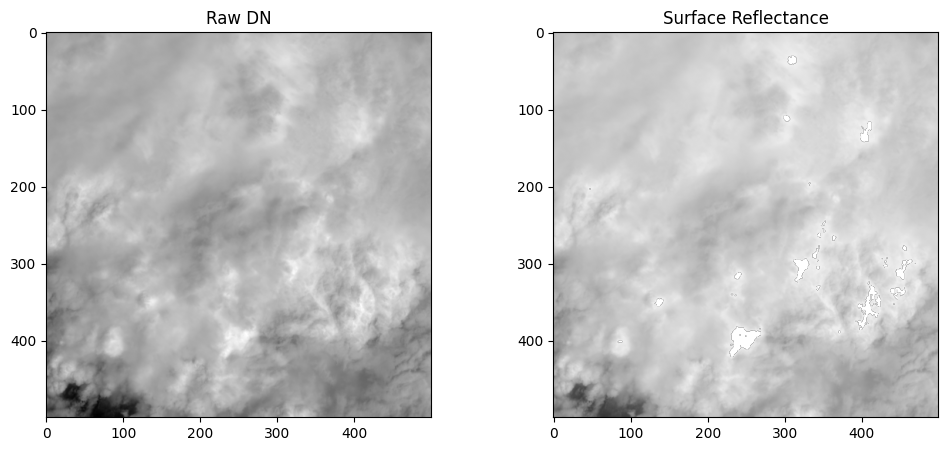

Plot saved.


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(band4, cmap='gray')
axes[0].set_title('Raw DN')

axes[1].imshow(sr, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Surface Reflectance')

plt.savefig('/content/Data/pipeline_comparison.png', dpi=150)
plt.show()
print("Plot saved.")